In [17]:
import numpy as np
import matplotlib.pyplot as plt

def create_exp_decay_matrix(n, d, alpha=0.1):
    # Create diagonal matrix with exponential decay
    s = np.exp(-alpha * np.arange(min(n, d)))
    U, _ = np.linalg.qr(np.random.randn(n, min(n, d)))
    V, _ = np.linalg.qr(np.random.randn(d, min(n, d)))
    return U @ np.diag(s) @ V.T, s, U, V.T

def create_linear_decay_matrix(n, d, alpha=0.1):
    # Create diagonal matrix with exponential decay
    s = np.linspace(1, alpha, min(n,d))
    U, _ = np.linalg.qr(np.random.randn(n, min(n, d)))
    V, _ = np.linalg.qr(np.random.randn(d, min(n, d)))
    return U @ np.diag(s) @ V.T, s, U, V

def plot_canonical_angles(Vt, Vt_exact, iteration, dir_path):
    # Compute the singular values of Q1.T @ Q2
    print(Vt.shape, Vt_exact.shape)
    s = np.linalg.svd(Vt @ Vt_exact[:Vt.shape[0], :].T, compute_uv=False)
    
    # Compute the angles in radians
    eps = 1e-6
    assert np.all(s > -1.0 - eps) and np.all(s < 1.0 + eps), "Invalid canonical correlation found" 
    angles = np.arccos(np.clip(s, -1.0, 1.0))
    print("Subspace angle 2:", max(angles), np.mean(angles))
    
    epsilon = 1e-4
    s = -np.log(np.maximum(1 - s, epsilon))
    # print(s)
    # Create the boxplot
    fig, ax = plt.subplots(figsize=(10, 8))
    bp = ax.boxplot(s, whis=1.5)
    
    # Extract positions
    whiskers = [item.get_ydata()[1] for item in bp['whiskers']]
    caps = [item.get_ydata()[0] for item in bp['caps']]
    boxes = [item.get_ydata() for item in bp['boxes']][0]
    medians = [item.get_ydata()[0] for item in bp['medians']]
    fliers = bp['fliers'][0].get_ydata()
    
    # Calculate statistics
    min_val, max_val = np.min(s), np.max(s)
    q1, median_val, q3 = np.percentile(s, [25, 50, 75])
    lower_whisker, upper_whisker = whiskers[0], whiskers[1]
    
    # Function to add annotation with offset
    def add_annotation(x, y, text, offset=0, color='black', ha='left', va='center'):
        ax.annotate(text, (x, y), xytext=(offset, 0), textcoords='offset points',
                    ha=ha, va=va, color=color)
    
    def inverse_transform(s):
        return 1 - np.exp(-s)
    
    # Add annotations with adjusted positions
    add_annotation(0.6, min_val+0.1, f'Min: {inverse_transform(min_val):.2f}', offset=5, va='bottom')
    add_annotation(0.6, max_val-0.1, f'Max: {inverse_transform(max_val):.2f}', offset=5, va='top')
    add_annotation(1.1, q1, f'Q1: {inverse_transform(q1):.2f}', offset=5)
    add_annotation(1.1+0.1, median_val, f'Median: {inverse_transform(median_val):.2f}', offset=5)
    add_annotation(1.1, q3, f'Q3: {inverse_transform(q3):.2f}', offset=5)
    add_annotation(1.1+0.1, lower_whisker, f'Lower whisker: {inverse_transform(lower_whisker):.2f}', offset=5, va='bottom')
    add_annotation(1.1+0.1, upper_whisker, f'Upper whisker: {inverse_transform(upper_whisker):.2f}', offset=5, va='top')
    
    # Add outlier information
    if len(fliers) > 0:
        outlier_min, outlier_max = np.min(fliers), np.max(fliers)
        add_annotation(0.78, outlier_min, f'Min outlier: {inverse_transform(outlier_min):.2f}', offset=5, va='bottom', color='red')
        add_annotation(0.78, outlier_max, f'Max outlier: {inverse_transform(outlier_max):.2f}', offset=5, va='top', color='red')
        add_annotation(0.78, (outlier_min+outlier_max)/2, f'Number of outliers: {len(fliers)}', offset=5, va='center', color='red')
    
    # Customize the plot
    ax.set_title('Boxplot with Non-Overlapping Annotations')
    ax.set_ylabel('Values')
    ax.set_xlim(0.5, 1.5)  # Adjust x-axis limits to make room for annotations
    ax.set_ylim(0, -np.log(epsilon)+0.1)
    
    y_ticks = np.array([0, 0.5, 0.9, 0.99, 0.999, 0.9999, 1])
    ax.set_yticks(-np.log(1 - y_ticks + epsilon))
    ax.set_yticklabels([f"{y}" for y in y_ticks])
    
    plt.grid()
    plt.tight_layout()
    # plt.savefig(dir_path + f'/angles_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')
    
def calculate_v_i_plus_1(V_i, G_w, s_i, k, t):
    # Ensure V_i is s_i x s_i
    assert V_i.shape == (s_i, s_i), f"V_i should be {s_i}x{s_i}, but is {V_i.shape}"
    
    # Ensure G_w is (k+t) x (k+t)
    assert G_w.shape == (k+t, k+t), f"G_w should be {k+t}x{k+t}, but is {G_w.shape}"
    
    # Create the block matrix [V_i 0; 0 I_t]
    block1 = np.block([
        [V_i, np.zeros((s_i, t))],
        [np.zeros((t, s_i)), np.eye(t)]
    ])
    
    # Create P matrix
    P = np.block([
        [np.eye(k), np.zeros((k, t)), np.zeros((k, s_i-k))],
        [np.zeros((s_i-k, k)), np.zeros((s_i-k, t)), np.eye(s_i-k)],
        [np.zeros((t, k)), np.eye(t), np.zeros((t, s_i-k))]
    ])
    
    # Create [G_w 0; 0 I_{s_i-k}]
    block2 = np.block([
        [G_w, np.zeros((k+t, s_i-k))],
        [np.zeros((s_i-k, k+t)), np.eye(s_i-k)]
    ])

    # Calculate V_{i+1}
    V_i_plus_1 = block1 @ P @ block2 @ P.T

    # Verify the shape of the result
    print("\nShape of V_{i+1}:", V_i_plus_1.shape)
    
    # Print shapes of intermediate matrices for debugging
    print("\nShapes of intermediate matrices:")
    print("block1:", block1.shape)
    print("P:", P.shape)
    print("block2:", block2.shape)
    
    return V_i_plus_1
    
def incremental_svd(A, window_size,
                    S_exact, Vt_exact, U_exact,):
    m, n = A.shape
    num_windows = n // window_size
    
    # Initialize with the first window
    Q, R = np.linalg.qr(A[:, :window_size])
    U, S, Vt = np.linalg.svd(R, full_matrices=False)
    Q = Q @ U#
    B = np.diag(S) 
    W = np.eye(window_size)
    W = W @ Vt.T #
    discarded_QRs = []
    V_i = None
    
    for j in range(1, num_windows):
        # Get the next window
        next_window = A[:, j*window_size:(j+1)*window_size]
        
        # Expand Q_j-1 * B_j-1 with A_j
        expanded = np.hstack([Q @ B, next_window])
        
        # Compute QR factorization
        Q, R = np.linalg.qr(expanded)
        
        # Update W
        W_new = np.zeros((W.shape[0] + window_size, W.shape[1] + window_size))
        W_new[:W.shape[0], :W.shape[1]] = W
        W_new[W.shape[0]:, W.shape[1]:] = np.eye(window_size)
        W = W_new

        # Check orthogonality of Q and W
        Q_orthogonality = np.linalg.norm(Q.T @ Q - np.eye(Q.shape[1]))
        W_orthogonality = np.linalg.norm(W.T @ W - np.eye(window_size*2))
        
        print(f"Q orthogonality error: {Q_orthogonality}")
        print(f"W orthogonality error: {W_orthogonality}")
        
        # Compute SVD of R
        U, S, Vt = np.linalg.svd(R, full_matrices=False)
        
        # Construct Gu (left singular vectors)
        Gu = U
        Gv = Vt.T

        # print(B.shape, Q.shape, W.shape, Gv.shape)
        # Update B, Q, and W
        B = np.diag(S) 
        print(B)
        Q = Q @ Gu
        W = W @ Gv

#         print("Q.shape, B.shape, R.shape, U.shape, expanded.shape", Q.shape, B.shape, R.shape, U.shape, expanded.shape)
        discarded_QRs.append(Q[:, window_size:] @ B[window_size:, window_size:])
        print(V_i.shape if np.any(V_i) else V_i)
        if np.any(V_i):
            s_i = j * window_size
            k, t = window_size, window_size
            V_i1 = calculate_v_i_plus_1(V_i, Gv, s_i, k, t)
            V_i = V_i1 
        else:
            V_i = Gv
        
        # Truncate to keep only top window_size singular values/vectors
        B = B[:window_size, :window_size]
        Q = Q[:, :window_size]
        W = W[:, :window_size]
        
        # Check orthogonality of Q and W
        Q_orthogonality = np.linalg.norm(Q.T @ Q - np.eye(window_size))
        W_orthogonality = np.linalg.norm(W.T @ W - np.eye(window_size))

        # save_spectrum_comparison(S, S_exact, 
        #                          A_norm, name, j, dir_path)
        # save_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
        #                A_norm, name, j, dir_path, is_sym_psd) 
        if j == num_windows-1:
            print(W.shape, Vt_exact.shape)
            plot_canonical_angles(W.T, Vt_exact, 
                                  j, "")
        
        print(f"Q orthogonality error: {Q_orthogonality}")
        print(f"W orthogonality error: {W_orthogonality}")

        print("="*30)
    return Q, B, W, discarded_QRs, V_i

def incremental_svd(A, window_size,
                    S_exact, Vt_exact, U_exact,):
    m, n = A.shape
    num_windows = n // window_size
    
    # Initialize with the first window
    
    U, S, Vt = np.linalg.svd(A[:, :window_size], full_matrices=False)
    B = U @ np.diag(S) 
    W = np.eye(window_size)
    W = W @ Vt.T 
    discarded_QRs = []
    V_i = None
    print(W[0, :10])
    print("B.shape, W.shape", B.shape, W.shape)
    
    for j in range(1, num_windows):
        # Get the next window
        next_window = A[:, j*window_size:(j+1)*window_size]
        
        # Expand Q_j-1 * B_j-1 with A_j
        expanded = np.hstack([B, next_window])
        print("expanded.shape", expanded.shape)
        
        # Update W
        W_new = np.zeros((W.shape[0] + window_size, W.shape[1] + window_size))
        W_new[:W.shape[0], :W.shape[1]] = W
        W_new[W.shape[0]:, W.shape[1]:] = np.eye(window_size)
        W = W_new
        
        # Compute SVD of R
        U, S, Vt = np.linalg.svd(expanded, full_matrices=False)
        
        print("V:", Vt.T[0,:10])
        
        # Construct Gu (left singular vectors)
        Gu = U
        Gv = Vt.T

        # print(B.shape, Q.shape, W.shape, Gv.shape)
        # Update B, Q, and W
        # 
        B = U @ np.diag(S) 
        W = W @ Gv
        print(W[0, :10])
        print(B[0, :10])
#         print("W", W.shape, Gv.shape)

#         print("Q.shape, B.shape, R.shape, U.shape, expanded.shape", Q.shape, B.shape, R.shape, U.shape, expanded.shape)
        discarded_QRs.append(B[:, window_size:])
        print(discarded_QRs[0][0, :3])
        print(V_i.shape if np.any(V_i) else V_i)
        if np.any(V_i):
            s_i = j * window_size
            k, t = window_size, window_size
            V_i1 = calculate_v_i_plus_1(V_i, Gv, s_i, k, t)
            V_i = V_i1 
        else:
            V_i = Gv
        
        # Truncate to keep only top window_size singular values/vectors
        B = B[:, :window_size]
        W = W[:, :window_size]
        
        # Check orthogonality of Q and W
        W_orthogonality = np.linalg.norm(W.T @ W - np.eye(window_size))

        # save_spectrum_comparison(S, S_exact, 
        #                          A_norm, name, j, dir_path)
        # save_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
        #                A_norm, name, j, dir_path, is_sym_psd) 
        if j == num_windows-1:
            print(W.shape, Vt_exact.shape)
            plot_canonical_angles(W.T, Vt_exact, 
                                  j, "")
        
#         print(f"Q orthogonality error: {Q_orthogonality}")
        print(f"W orthogonality error: {W_orthogonality}")

        print("="*30)
    Q = np.eye(B.shape[0])
    return Q, B, W, discarded_QRs, V_i

# def incremental_svd(A, window_size,
#                     S_exact, Vt_exact, U_exact,):
#     A = A.T
#     m, n = A.shape
#     num_windows = n // window_size
    
#     # Initialize with the first window
#     U, S, Vt = np.linalg.svd(A[:window_size, :], full_matrices=False)
#     # A.T = V @ S @ U.T, so A.T = (BW.T).T = WB.T = W @ S @ U.T  
    
#     B = np.diag(S) @ Vt
#     W = np.eye(window_size)
#     W = W @ U 
#     discarded_QRs = []
#     V_i = None
    
#     for j in range(1, num_windows):
#         # Get the next window
#         next_window = A[j*window_size:(j+1)*window_size, :]
        
#         # Expand Q_j-1 * B_j-1 with A_j
#         print("B.shape, next_window.shape:", B.shape, next_window.shape)
#         expanded = np.vstack([B, next_window])
        
#         # Update W
#         W_new = np.zeros((W.shape[0] + window_size, W.shape[1] + window_size))
#         W_new[:W.shape[0], :W.shape[1]] = W
#         W_new[W.shape[0]:, W.shape[1]:] = np.eye(window_size)
#         W = W_new
        
#         # Compute SVD of R
#         U, S, Vt = np.linalg.svd(expanded, full_matrices=False)
        
#         # Construct Gu (left singular vectors)
#         Gu = U
#         Gv = Vt.T

#         # print(B.shape, Q.shape, W.shape, Gv.shape)
#         # Update B, Q, and W
#         print("W", W.shape, Gu.shape)
#         B = np.diag(S) @ Vt
#         W = W @ Gu 
        

# #         print("Q.shape, B.shape, R.shape, U.shape, expanded.shape", Q.shape, B.shape, R.shape, U.shape, expanded.shape)
#         discarded_QRs.append(B[:, window_size:])
#         print(V_i.shape if np.any(V_i) else V_i)
# #         if np.any(V_i):
# #             s_i = j * window_size
# #             k, t = window_size, window_size
# #             V_i1 = calculate_v_i_plus_1(V_i, Gv, s_i, k, t)
# #             V_i = V_i1 
# #         else:
# #             V_i = Gv
        
#         # Truncate to keep only top window_size singular values/vectors
#         B = B[:window_size, :]
#         W = W[:, :window_size]
        
#         # Check orthogonality of Q and W
#         W_orthogonality = np.linalg.norm(W.T @ W - np.eye(W.shape[1]))

#         # save_spectrum_comparison(S, S_exact, 
#         #                          A_norm, name, j, dir_path)
#         # save_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
#         #                A_norm, name, j, dir_path, is_sym_psd) 
#         if j == num_windows-1:
#             print(W.shape, U_exact.shape)
#             plot_canonical_angles(W.T, U_exact.T, 
#                                   j, "")
        
# #         print(f"Q orthogonality error: {Q_orthogonality}")
#         print(f"W orthogonality error: {W_orthogonality}")

#         print("="*30)
#     Q = np.eye(B.shape[1])
    
#     return W, B, Q, discarded_QRs, V_i

def incremental_svd(A, window_size,
                    S_exact, Vt_exact, U_exact,
                    early_stop=None):
    A = A.T
    m, n = A.shape
    num_windows = n // window_size
    
    # Initialize with the first window
    
    U, S, Vt = np.linalg.svd(A[:window_size, :], full_matrices=False)
    # A.T = V @ S @ U.T, so A.T = (BW.T).T = WB.T = W @ S @ U.T  
    # W = W @ V
    # V is U, U is V
    print(S, Vt[0,:10])
    
    # B is not B.T
    B = np.diag(S) @ Vt
    W = np.eye(window_size)
    W = W @ U
    discarded_QRs = []
    V_i = None
    print(W[0, :10])
    print("B.shape, W.shape", B.shape, W.shape)
    
    for j in range(1, num_windows):
        if early_stop and early_stop <= j:
            discarded_QRs.append(A[j*window_size:, :])
            W_new = np.zeros((n, window_size))
            W_new[:W.shape[0], :W.shape[1]] = W
            W = W_new
#             W_new[W.shape[0]:W.shape[0]+window_size, W.shape[1]:] = np.eye(window_size)
            break
        
        # Get the next window
        next_window = A[j*window_size:(j+1)*window_size, :]
        
        # Expand Q_j-1 * B_j-1 with A_j
        expanded = np.vstack([B, next_window])
        print("expanded.shape", expanded.shape)
        
        # Update W
        W_new = np.zeros((W.shape[0] + window_size, W.shape[1] + window_size))
        W_new[:W.shape[0], :W.shape[1]] = W
        W_new[W.shape[0]:, W.shape[1]:] = np.eye(window_size)
        W = W_new
        
        # Compute SVD of R
        U, S, Vt = np.linalg.svd(expanded, full_matrices=False)
        print("V:", U[0,:10])

        # print(B.shape, Q.shape, W.shape, Gv.shape)
        # Update B, Q, and W
        # 
        print("W", W.shape, U.shape)
        B = S.reshape(-1, 1) * Vt #np.diag(S) @ Vt
        W = W @ U
        print(W[0, :10])
#         print(B[:10, 0])
        print("B", B[0,:10])
        

#         print("Q.shape, B.shape, R.shape, U.shape, expanded.shape", Q.shape, B.shape, R.shape, U.shape, expanded.shape)
#         discarded_QRs.append(B[window_size:, :])
        discarded_QRs.append(S[window_size:].reshape(-1, 1) * Vt[window_size:, :])
        print(discarded_QRs[0][:3, 0])
#         print(V_i.shape if np.any(V_i) else V_i)
#         if np.any(V_i):
#             s_i = j * window_size
#             k, t = window_size, window_size
#             V_i1 = calculate_v_i_plus_1(V_i, Gv, s_i, k, t)
#             V_i = V_i1 
#         else:
#             V_i = Gv
        
        # Truncate to keep only top window_size singular values/vectors
        B = B[:window_size, :]
        W = W[:, :window_size]
        
        # Check orthogonality of Q and W
        W_orthogonality = np.linalg.norm(W.T @ W - np.eye(window_size))

        # save_spectrum_comparison(S, S_exact, 
        #                          A_norm, name, j, dir_path)
        # save_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
        #                A_norm, name, j, dir_path, is_sym_psd) 
        if j == num_windows-1:
            print(W.shape, Vt_exact.shape)
            plot_canonical_angles(W.T, Vt_exact, 
                                  j, "")
        
#         print(f"Q orthogonality error: {Q_orthogonality}")
        print(f"W orthogonality error: {W_orthogonality}")

        print("="*30)
    Q = np.eye(B.shape[1])
    return Q, B.T, W, discarded_QRs, V_i
    

[0.67046576 0.53558155 0.4572272  0.40180322 0.30094619] [-0.17880817  0.06425506  0.06128822 -0.03622961  0.28754869 -0.11652483
 -0.16190482  0.28884378  0.23775601 -0.17436752]
[-0.53410791 -0.22827024  0.25604349  0.77269621 -0.00193387]
B.shape, W.shape (5, 20) (5, 5)
expanded.shape (10, 20)
V: [-0.27660309  0.69410227  0.23322156  0.5506228  -0.17230502  0.09739591
 -0.19676733 -0.05934623  0.01000243 -0.05119201]
W (10, 10) (10, 10)
[ 0.02325715 -0.43178298 -0.31099679 -0.10232737  0.26783737 -0.48123926
  0.07908706 -0.46328066  0.17894608  0.3867805 ]
B [ 0.35100326 -0.17476704 -0.23458259 -0.13026102 -0.07127781  0.32086265
 -0.08975087 -0.20006124 -0.09588701 -0.02383539]
[0.0417997  0.06278564 0.09410685]
W orthogonality error: 2.8129731101912647e-15
expanded.shape (10, 20)
V: [-0.63952796  0.49152208 -0.13792021 -0.12030368  0.31191543  0.2617647
  0.17279705  0.21261354  0.22674805  0.15370445]
W (15, 10) (10, 10)
[ 0.11467726  0.26527923 -0.27364565 -0.08792612 -0.404420

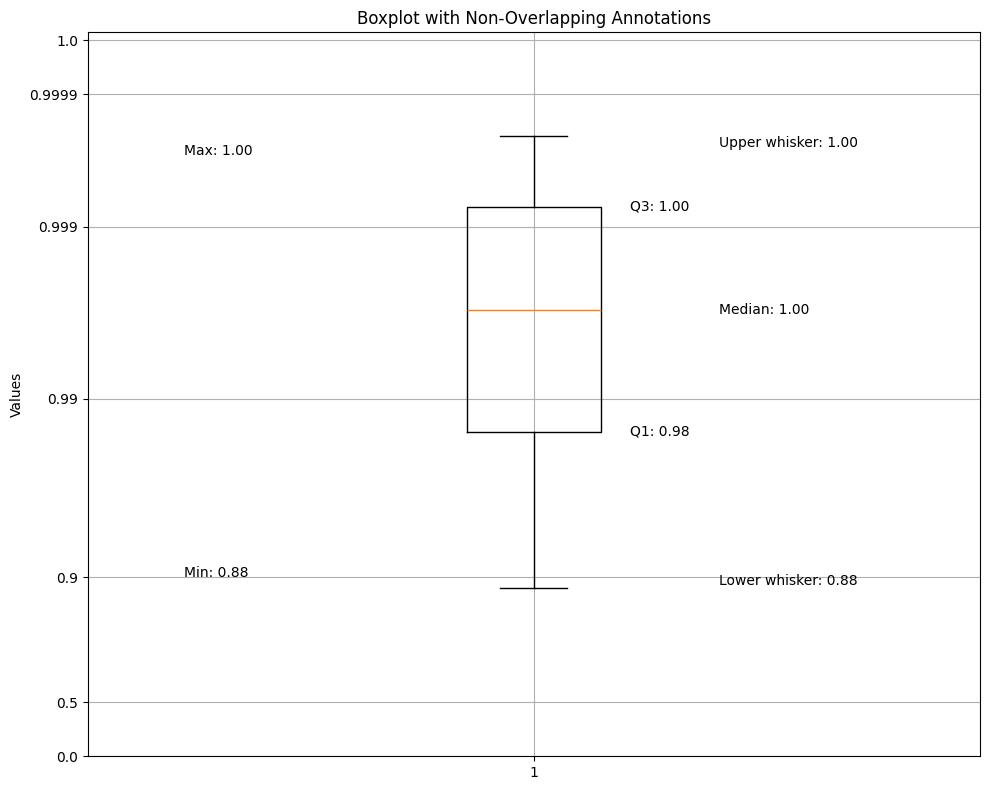

W orthogonality error: 3.5417664338360643e-15
Discarded: (20, 15)
Norm of the error: 1.4059566310009324 (frobenius), 0.6258505923350733 (L2)
Norm of discarded: 0.625850592335073
Norm of the error (direct SVD): 1.3886767426508653 (frobenius), 0.6065306597126335 (L2)
W orthogonality error: 3.5417664338360643e-15


In [21]:
def create_exp_decay_matrix(n, d, alpha=0.1):
    np.random.seed(0)
    # Create diagonal matrix with exponential decay
    s = np.exp(-alpha * np.arange(min(n, d)))
    U, _ = np.linalg.qr(np.random.randn(n, min(n, d)))
    V, _ = np.linalg.qr(np.random.randn(d, min(n, d)))
    return U @ np.diag(s) @ V.T, s, V.T, U 

# Create a test matrix
m, n = 20, 20
# A = np.random.rand(m, n)
# A = create_linear_decay_matrix(m, n, alpha=0.1)
A, S_exact, Vt_exact, U_exact = create_exp_decay_matrix(m, n, alpha=0.1)

# Set window size
window_size = 5

# Compute incremental SVD
Q, B, W, discarded_QRs, V_i = incremental_svd(A, window_size,
                         S_exact, Vt_exact, U_exact,
                                             early_stop=0)
# discarded_QRs = np.concatenate(discarded_QRs, axis=1) if discarded_QRs else discarded_QRs
discarded_QRs = np.concatenate(discarded_QRs, axis=0).T if discarded_QRs else discarded_QRs
print("Discarded:", discarded_QRs.shape)

# Reconstruct the approximation
if np.any(W):
    A_approx = Q @ B @ W.T
else:
    A = A.T @ A
    A_approx = Q @ B
    A_approx = A_approx.T @ A_approx
# A_approx = Q @ B
# A_approx = np.random.rand(m, n)
# A = create_linear_decay_matrix(m, n, alpha=0.1)
# A_approx, _, _, _ = create_exp_decay_matrix(m, n, alpha=0.1)

# Compute error
error = np.linalg.norm(A - A_approx, 'fro')
error_L2 = np.linalg.norm(A - A_approx, 2)

print(f"Norm of the error: {error} (frobenius), {error_L2} (L2)")
print(f"Norm of discarded: {np.linalg.norm(discarded_QRs.T, 2)}")

# Compare with direct SVD
U, S, Vt = np.linalg.svd(A, full_matrices=False)
A_svd = U[:, :window_size] @ np.diag(S[:window_size]) @ Vt[:window_size, :]

svd_error = np.linalg.norm(A - A_svd, 'fro')
svd_error_L2 = np.linalg.norm(A - A_svd, 2)

print(f"Norm of the error (direct SVD): {svd_error} (frobenius), {svd_error_L2} (L2)")

# Check orthogonality of Q and W
# Q_orthogonality = np.linalg.norm(Q.T @ Q - np.eye(window_size))
W_orthogonality = np.linalg.norm(W.T @ W - np.eye(W.shape[1]))

# print(f"Q orthogonality error: {Q_orthogonality}")
print(f"W orthogonality error: {W_orthogonality}")

In [22]:
np.linalg.norm(A.T)

2.327147286895328

In [9]:
B.shape, W.shape

((20, 5), (20, 5))

In [464]:
# Compare with direct SVD
U, S, Vt = np.linalg.svd(A, full_matrices=False)
A_svd = U[:, :window_size] @ np.diag(S[:window_size]) @ Vt[:window_size, :]

svd_error = np.linalg.norm(A - A_svd, 'fro')
svd_error_L2 = np.linalg.norm(A - A_svd, 2)

print(f"Norm of the error (direct SVD): {svd_error} (frobenius), {svd_error_L2} (L2)")

# Check orthogonality of Q and W
# Q_orthogonality = np.linalg.norm(Q.T @ Q - np.eye(window_size))
W_orthogonality = np.linalg.norm(W.T @ W - np.eye(W.shape[1]))

# print(f"Q orthogonality error: {Q_orthogonality}")
print(f"W orthogonality error: {W_orthogonality}")

Norm of the error (direct SVD): 1.3886767426508653 (frobenius), 0.6065306597126335 (L2)
W orthogonality error: 3.5417664338360643e-15


In [463]:
A[0,:10]

array([-0.03013198, -0.12912021,  0.0435414 ,  0.0485535 , -0.07883288,
       -0.08485206, -0.27456257, -0.0664139 , -0.29488917,  0.13915405])

[ 0.53410791 -0.22827024 -0.25604349 -0.77269621  0.00193387]
B.shape, W.shape (20, 5) (5, 5)
expanded.shape (20, 10)
V: [-0.27660309  0.69410227 -0.23322156  0.5506228  -0.17230502  0.09739591
 -0.19676733 -0.05934623  0.01000243  0.05119201]
[-0.02325715  0.43178298 -0.31099679  0.10232737 -0.26783737  0.48123926
 -0.07908706  0.46328066 -0.17894608  0.3867805 ]
[-0.35100326  0.16261326  0.17955371 -0.10649811  0.0129309  -0.0417997
 -0.06278564 -0.09410685 -0.11586957 -0.00075928]
None
W orthogonality error: 2.200671877848728e-15
expanded.shape (20, 10)
V: [ 0.63952796 -0.49152208  0.13792021  0.12030368  0.31191543 -0.2617647
 -0.17279705  0.21261354 -0.22674805  0.15370445]
[ 0.11467726  0.26527923 -0.27364565 -0.08792612  0.40442027  0.00655345
  0.00467364 -0.1166725   0.12743822  0.07933334]
[-0.30710138  0.06881564 -0.23608903  0.03028822 -0.10924532  0.27565794
 -0.08983049 -0.03771277 -0.00799417  0.03288575]
(10, 10)

Shape of V_{i+1}: (15, 15)

Shapes of intermediate matri

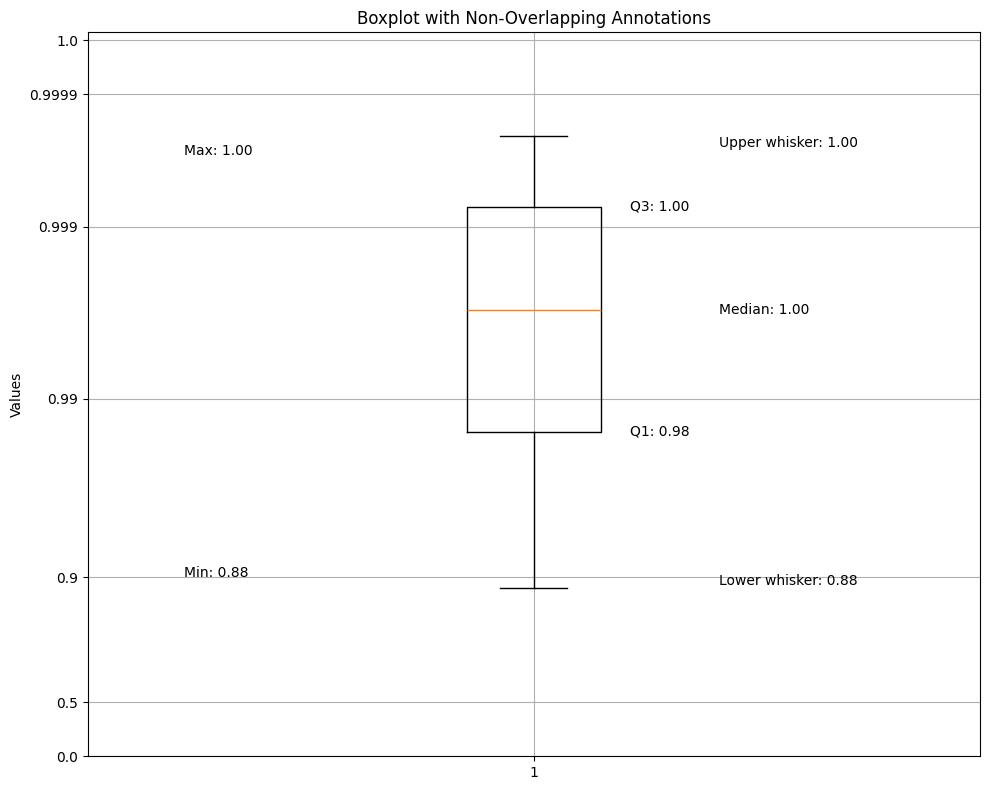

W orthogonality error: 3.468181117310828e-15


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [431]:
def create_exp_decay_matrix(n, d, alpha=0.1):
    np.random.seed(0)
    # Create diagonal matrix with exponential decay
    s = np.exp(-alpha * np.arange(min(n, d)))
    U, _ = np.linalg.qr(np.random.randn(n, min(n, d)))
    V, _ = np.linalg.qr(np.random.randn(d, min(n, d)))
    return U @ np.diag(s) @ V.T, s, V.T, U 

# Create a test matrix
m, n = 20, 20
# A = np.random.rand(m, n)
# A = create_linear_decay_matrix(m, n, alpha=0.1)
A, S_exact, Vt_exact, U_exact = create_exp_decay_matrix(m, n, alpha=0.1)

# Set window size
window_size = 5

# Compute incremental SVD
Q, B, W, discarded_QRs_old, V_i = incremental_svd(A, window_size,
                         S_exact, Vt_exact, U_exact)
# discarded_QRs = np.concatenate(discarded_QRs, axis=1) if discarded_QRs else discarded_QRs
discarded_QRs = np.concatenate(discarded_QRs, axis=0).T if discarded_QRs else discarded_QRs
print("Discarded:", discarded_QRs.shape)

# Reconstruct the approximation
if np.any(W):
    A_approx = Q @ B @ W.T
else:
    A = A.T @ A
    A_approx = Q @ B
    A_approx = A_approx.T @ A_approx
# A_approx = Q @ B
# A_approx = np.random.rand(m, n)
# A = create_linear_decay_matrix(m, n, alpha=0.1)
# A_approx, _, _, _ = create_exp_decay_matrix(m, n, alpha=0.1)

# Compute error
error = np.linalg.norm(A - A_approx, 'fro')
error_L2 = np.linalg.norm(A - A_approx, 2)

print(f"Norm of the error: {error} (frobenius), {error_L2} (L2)")
print(f"Norm of discarded: {np.linalg.norm(discarded_QRs.T, 2)}")

# Compare with direct SVD
U, S, Vt = np.linalg.svd(A, full_matrices=False)
A_svd = U[:, :window_size] @ np.diag(S[:window_size]) @ Vt[:window_size, :]

svd_error = np.linalg.norm(A - A_svd, 'fro')
svd_error_L2 = np.linalg.norm(A - A_svd, 2)

print(f"Norm of the error (direct SVD): {svd_error} (frobenius), {svd_error_L2} (L2)")

# Check orthogonality of Q and W
# Q_orthogonality = np.linalg.norm(Q.T @ Q - np.eye(window_size))
W_orthogonality = np.linalg.norm(W.T @ W - np.eye(W.shape[1]))

# print(f"Q orthogonality error: {Q_orthogonality}")
print(f"W orthogonality error: {W_orthogonality}")

In [438]:
discarded_QRs_old[0][0,:10]

array([-0.0417997 , -0.06278564, -0.09410685, -0.11586957, -0.00075928])

In [436]:
discarded_QRs[0][0]

0.35100325838798563

In [417]:
discarded_QRs.shape

(20, 15)

In [423]:
discarded_QRs.T.shape

(20, 15)

In [407]:
Q.shape, B.shape, W.shape

((20, 20), (20, 5), (20, 5))

In [266]:
Q, R = np.linalg.qr(A) 
U, S, Vt = np.linalg.svd(R, full_matrices=False) 
Q = Q @ U #
B = np.diag(S) 
W = np.eye(window_size) 
W = W @ Vt #

np.diag(B)

array([1.        , 0.90483742, 0.81873075, 0.74081822, 0.67032005,
       0.60653066, 0.54881164, 0.4965853 , 0.44932896, 0.40656966,
       0.36787944, 0.33287108, 0.30119421, 0.27253179, 0.24659696,
       0.22313016, 0.20189652, 0.18268352, 0.16529889, 0.14956862])

In [275]:
Q, R = np.linalg.qr(A)
U, S, Vt = np.linalg.svd(R, full_matrices=False)

A - Q @ U @ B @ Vt

array([[ 1.38777878e-16, -3.74700271e-16,  7.63278329e-17,
        -2.22044605e-16,  5.41233725e-16,  4.51028104e-17,
         5.55111512e-17, -8.32667268e-17, -1.66533454e-16,
         2.77555756e-17,  5.82867088e-16,  7.63278329e-17,
         0.00000000e+00, -5.55111512e-16, -1.66533454e-16,
        -1.24900090e-16, -8.32667268e-17, -1.11022302e-16,
        -3.88578059e-16,  2.94902991e-17],
       [ 0.00000000e+00, -2.35922393e-16, -1.64798730e-17,
        -1.59594560e-16,  1.66533454e-16,  1.38777878e-17,
         1.73472348e-16, -7.28583860e-17,  2.22044605e-16,
        -6.26668856e-17,  1.49186219e-16,  1.24900090e-16,
         3.12250226e-16,  5.55111512e-17,  3.20923843e-17,
        -1.66533454e-16, -3.46944695e-17, -1.07552856e-16,
         3.60822483e-16,  9.71445147e-17],
       [ 8.32667268e-17,  2.77555756e-17,  1.56125113e-16,
        -2.49800181e-16, -1.11022302e-16,  2.77555756e-16,
        -1.52655666e-16, -2.77555756e-17, -1.94289029e-16,
         3.05311332e-16,  5.5

In [277]:
(Q@U)[0]

array([ 0.34711171, -0.19082945,  0.19357793, -0.09017893,  0.09137845,
        0.04675761, -0.08761234, -0.32318445,  0.29621596,  0.40618526,
        0.2320946 , -0.15784422,  0.25636472, -0.13426226,  0.04711589,
       -0.20148293,  0.27675997, -0.22828236,  0.28940053, -0.06552391])

In [268]:
Q[0]

array([ 0.34711171, -0.19082945,  0.19357793, -0.09017893,  0.09137845,
        0.04675761, -0.08761234, -0.32318445,  0.29621596,  0.40618526,
        0.2320946 , -0.15784422,  0.25636472, -0.13426226,  0.04711589,
       -0.20148293,  0.27675997, -0.22828236,  0.28940053, -0.06552391])

In [246]:
np.diag(B), S_exact

(array([1.        , 0.90483742, 0.81873075, 0.74081822, 0.67032005,
        0.60653066, 0.54881164, 0.4965853 , 0.44932896, 0.40656966,
        0.36787944, 0.33287108, 0.30119421, 0.27253179, 0.24659696,
        0.22313016, 0.20189652, 0.18268352, 0.16529889, 0.14956862]),
 array([1.        , 0.90483742, 0.81873075, 0.74081822, 0.67032005,
        0.60653066, 0.54881164, 0.4965853 , 0.44932896, 0.40656966,
        0.36787944, 0.33287108, 0.30119421, 0.27253179, 0.24659696,
        0.22313016, 0.20189652, 0.18268352, 0.16529889, 0.14956862]))

In [269]:
Q[0], U_exact[0]

(array([ 0.34711171, -0.19082945,  0.19357793, -0.09017893,  0.09137845,
         0.04675761, -0.08761234, -0.32318445,  0.29621596,  0.40618526,
         0.2320946 , -0.15784422,  0.25636472, -0.13426226,  0.04711589,
        -0.20148293,  0.27675997, -0.22828236,  0.28940053, -0.06552391]),
 array([-0.34711171,  0.19082945, -0.19357793,  0.09017893, -0.09137845,
         0.04675761, -0.08761234, -0.32318445,  0.29621596,  0.40618526,
         0.2320946 , -0.15784422, -0.25636472, -0.13426226, -0.04711589,
        -0.20148293, -0.27675997, -0.22828236,  0.28940053,  0.06552391]))

In [228]:
Q.shape, B.shape, W.shape

((5, 5), (5, 5), (20, 20))

In [220]:
discarded_QRs

array([], shape=(5, 0), dtype=float64)

In [221]:
np.linalg.norm((A @ V_i)[:, 50:])

0.0

In [199]:
import numpy as np

def calculate_v_i_plus_1(V_i, G_w, s_i, k, t):
    # Ensure V_i is s_i x s_i
    assert V_i.shape == (s_i, s_i), f"V_i should be {s_i}x{s_i}, but is {V_i.shape}"
    
    # Ensure G_w is (k+t) x (k+t)
    assert G_w.shape == (k+t, k+t), f"G_w should be {k+t}x{k+t}, but is {G_w.shape}"
    
    # Create the block matrix [V_i 0; 0 I_t]
    block1 = np.block([
        [V_i, np.zeros((s_i, t))],
        [np.zeros((t, s_i)), np.eye(t)]
    ])
    
    # Create P matrix
    P = np.block([
        [np.eye(k), np.zeros((k, t)), np.zeros((k, s_i-k))],
        [np.zeros((s_i-k, k)), np.zeros((s_i-k, t)), np.eye(s_i-k)],
        [np.zeros((t, k)), np.eye(t), np.zeros((t, s_i-k))]
    ])
    
    # Create [G_w 0; 0 I_{s_i-k}]
    block2 = np.block([
        [G_w, np.zeros((k+t, s_i-k))],
        [np.zeros((s_i-k, k+t)), np.eye(s_i-k)]
    ])

    # Calculate V_{i+1}
    V_i_plus_1 = block1 @ P @ block2 @ P.T

    # Verify the shape of the result
    print("\nShape of V_{i+1}:", V_i_plus_1.shape)
    
    # Print shapes of intermediate matrices for debugging
    print("\nShapes of intermediate matrices:")
    print("block1:", block1.shape)
    print("P:", P.shape)
    print("block2:", block2.shape)
    
    return V_i_plus_1

# Example usage
s_i = 5
k = 2
t = 3

# Create example matrices
V_i = np.random.rand(s_i, s_i)
G_w = np.random.rand(k+t, k+t)

# Calculate V_{i+1}
V_i1 = calculate_v_i_plus_1(V_i, G_w, s_i, k, t)

print("V_{i+1}:")
print(V_i1)




Shape of V_{i+1}: (8, 8)

Shapes of intermediate matrices:
block1: (8, 8)
P: (8, 8)
block2: (8, 8)
V_{i+1}:
[[1.32411294 0.80150601 0.89512646 0.16396411 0.25567521 0.54400398
  1.07681275 0.8335461 ]
 [1.05500639 0.91154141 0.52179818 0.68293688 0.74677387 0.49070799
  0.90478845 0.44396081]
 [0.70163714 0.87109034 0.26196466 0.02612883 0.56915804 0.38192053
  0.64717258 0.08158483]
 [1.06024214 0.91525732 0.22170071 0.17107969 0.1009439  0.49297376
  0.90914011 0.44681579]
 [0.59859145 0.41126989 0.98105614 0.16645154 0.00355438 0.25619471
  0.49518918 0.33734533]
 [0.7758624  0.55550544 0.         0.         0.         0.2695958
  0.73781536 0.11785114]
 [0.80150911 0.74280332 0.         0.         0.         0.91980123
  0.90071369 0.5426304 ]
 [0.15136891 0.48751253 0.         0.         0.         0.69340178
  0.91134358 0.09271338]]


In [198]:
V_i @ G_w

array([[0.83230374, 1.21066549, 1.39075323, 1.04268334, 1.65850242],
       [0.83020091, 1.65167599, 1.06675026, 1.11806124, 1.92983871],
       [0.97364688, 1.3000118 , 1.51284965, 1.24388078, 1.84146789],
       [0.87493547, 1.39215743, 1.31282886, 0.89966923, 1.41497697],
       [1.2510607 , 2.0239194 , 1.67297404, 1.4768503 , 2.28989841]])

In [163]:
Norm of the error: 3.3241317518746127 (frobenius), 1.0714245754531337 (L2)
Norm of the error (direct SVD): 6.205500815326108e-15 (frobenius), 3.137371483924061e-15 (L2)


Norm of the error: 1.1296680089310447 (frobenius), 0.46607679867993707 (L2)
Norm of the error (direct SVD): 5.5865182080923965e-15 (frobenius), 3.0876975215609393e-15 (L2)

SyntaxError: invalid syntax (2969757882.py, line 1)

In [164]:
Q.shape, B.shape, W.shape if W else None

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [32]:
A.shape, A_approx.shape

((1000, 1000), (50, 50))

In [107]:
def incremental_svd(A, window_size):
    m, n = A.shape
    num_windows = n // window_size
    
    # Initialize with the first window
    Q, R = np.linalg.qr(A[:, :window_size])
    B = R
    
    for j in range(1, num_windows):
        # Get the next window
        next_window = A[:, j*window_size:(j+1)*window_size]
        
        # Expand Q_j-1 * B_j-1 with A_j
        expanded = np.hstack([Q @ B, next_window])
        
        # Compute QR factorization
        Q, R = np.linalg.qr(expanded)
        
        # Compute SVD of R
        U, S, Vt = np.linalg.svd(R, full_matrices=False)
        
        # Truncate to keep only top window_size singular values/vectors
        U = U[:, :window_size]
        S = S[:window_size]
        Vt = Vt[:window_size, :]
        
        # Update B
        B = np.diag(S) @ Vt
        
        # Truncate Q
        Q = Q[:, :window_size]
    
    return Q, B

def incremental_svd(A, window_size):
    m, n = A.shape
    num_windows = n // window_size
    
    # Initialize with the first window
    B = A[:, :window_size]
    
    for j in range(1, num_windows):
        # Get the next window
        next_window = A[:, j*window_size:(j+1)*window_size]
        
        # Expand Q_j-1 * B_j-1 with A_j
        expanded = np.hstack([B, next_window])
        
        # Compute SVD of R
        U, S, Vt = np.linalg.svd(expanded, full_matrices=False)
        
        # Truncate to keep only top window_size singular values/vectors
        U = U[:, :window_size]
        S = S[:window_size]
        Vt = Vt[:window_size, :]
        
        # Update B
        B = U @ np.diag(S) 
        print(B.shape)
    Q = np.eye(B.shape[0],B.shape[0])
    return Q, B

In [108]:
# Create a test matrix
m, n = 100, 1000
A = np.random.rand(m, n)


# Set window size
window_size = 50

# Compute incremental SVD
Q, B = incremental_svd(A, window_size)

# Reconstruct the approximation
A_approx = Q @ B
# A_approx = np.random.rand(m, n)

# Compute error
error = np.linalg.norm(A - A_approx, 'fro')

print(f"Frobenius norm of the error: {error}")

# Compare with direct SVD
U, S, Vt = np.linalg.svd(A, full_matrices=False)
A_svd = U[:, :window_size] @ np.diag(S[:window_size]) @ Vt[:window_size, :]

svd_error = np.linalg.norm(A - A_svd, 'fro')

print(f"Frobenius norm of the error (direct SVD): {svd_error}")


(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)
(100, 50)


ValueError: operands could not be broadcast together with shapes (100,1000) (100,50) 

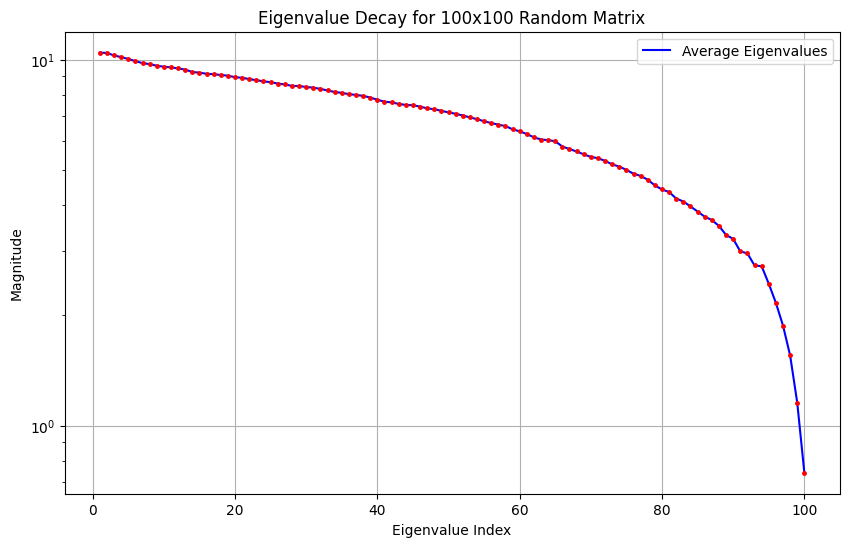

Largest eigenvalue: 10.4442
Smallest eigenvalue: 0.7434
Ratio of largest to smallest: 14.0485
Theoretical prediction for largest eigenvalue: 10.0000


In [114]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_eigenvalue_decay(n, num_trials=10):
    eigenvalues = []
    for _ in range(num_trials):
        # Create a random n x n matrix
        # A = np.random.randn(n, n)
        A = create_exp_decay_matrix(n, n, alpha=0.1)
        
        # Compute eigenvalues
        eig_vals = np.abs(np.linalg.eigvals(A))
        
        # Sort eigenvalues in descending order
        eig_vals = np.sort(eig_vals)[::-1]
        
        eigenvalues.append(eig_vals)
    
    # Average over trials
    avg_eigenvalues = np.mean(eigenvalues, axis=0)
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n+1), avg_eigenvalues, 'b-', label='Average Eigenvalues')
    plt.plot(range(1, n+1), avg_eigenvalues, 'r.', markersize=5)
    plt.title(f'Eigenvalue Decay for {n}x{n} Random Matrix')
    plt.xlabel('Eigenvalue Index')
    plt.ylabel('Magnitude')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Compute and print some statistics
    print(f"Largest eigenvalue: {avg_eigenvalues[0]:.4f}")
    print(f"Smallest eigenvalue: {avg_eigenvalues[-1]:.4f}")
    print(f"Ratio of largest to smallest: {avg_eigenvalues[0]/avg_eigenvalues[-1]:.4f}")
    print(f"Theoretical prediction for largest eigenvalue: {np.sqrt(n):.4f}")

# Run the analysis
if __name__ == "__main__":
    analyze_eigenvalue_decay(100)

In [106]:
import numpy as np

def create_exp_decay_matrix(n, d, alpha=0.1):
#     np.random.seed(0)
    # Create diagonal matrix with exponential decay
    s = np.exp(-alpha * np.arange(min(n, d)))
    U, _ = np.linalg.qr(np.random.randn(n, min(n, d)))
    V, _ = np.linalg.qr(np.random.randn(d, min(n, d)))
    return U @ np.diag(s) @ V.T, s, V.T, U 

# Create a test matrix
m, n = 20, 20
# A = np.random.rand(m, n)
# A = create_linear_decay_matrix(m, n, alpha=0.1)
A, S, Vt, U = create_exp_decay_matrix(m, n, alpha=0.1)

# Step 3: Define u (random vector) and e_i (standard basis vector)
# u = np.random.rand(n).reshape(-1,1)
u = U[:,0].reshape(-1,1)
i = 2  # Choosing i-th standard basis vector (2nd for example)
e_i = np.zeros(n).reshape(-1,1)
e_i[i] = 1

# Step 4: Create the rank-1 update matrix E
E = np.outer(u, e_i)

# Step 5: Compute A + E and its largest singular value (||A + E||)
A_plus_E = A + E
U_, singular_values_A_plus_E, Vt_ = np.linalg.svd(A_plus_E)
max_singular_value_A_plus_E = np.max(singular_values_A_plus_E)

# Step 6: Compute the largest singular value of A (||A||)
singular_values_A = np.linalg.svd(A, compute_uv=False)
max_singular_value_A = np.max(singular_values_A)

# Step 7: Find the lower bound for ||A + E|| - ||A||
w = np.dot(U.T, u)  # w = U^T * u
z = np.dot(Vt, e_i)  # z = V^T * e_i

# Step 8: Computing the sum for the lower bound S
S_ = sum((w[i] * z[i])**2 / (singular_values_A_plus_E[0] - S[i]) for i in range(1, n))

# Step 9: Lower bound for ||A + E|| - ||A||
lower_bound = (w[0] * z[0])**2 / (1 - S_)

# Outputs
{
    "max_singular_value_A_plus_E": max_singular_value_A_plus_E,
    "max_singular_value_A": max_singular_value_A,
    "||A + E|| - ||A||": max_singular_value_A_plus_E - max_singular_value_A,
    "lower_bound": lower_bound
}

{'max_singular_value_A_plus_E': 1.1602614611415352,
 'max_singular_value_A': 1.0000000000000002,
 '||A + E|| - ||A||': 0.16026146114153494,
 'lower_bound': array([0.19699458])}

In [111]:
sum((w[i] * z[i])**2 / (singular_values_A_plus_E[0] - S[i]) for i in range(0, n))


array([1.22920741])

In [150]:
singular_values_A_plus_E

array([1.16026146, 0.90472221, 0.80787813, 0.73025481, 0.66123976,
       0.54881487, 0.50367584, 0.47375948, 0.44556262, 0.40315719,
       0.35787041, 0.32655595, 0.2878608 , 0.261243  , 0.24659326,
       0.20235392, 0.19482956, 0.17637571, 0.1502729 , 0.14284265])

In [177]:
np.linalg.svd(new_S, compute_uv=False)

array([1.16026146, 0.90472221, 0.80787813, 0.73025481, 0.66123976,
       0.54881487, 0.50367584, 0.47375948, 0.44556262, 0.40315719,
       0.35787041, 0.32655595, 0.2878608 , 0.261243  , 0.24659326,
       0.20235392, 0.19482956, 0.17637571, 0.1502729 , 0.14284265])

In [178]:
new_S = (np.diag(S) + w @ z.T)
evals, _ = np.linalg.eig(new_S)
evals[::-1].sort()
evals

array([0.90483742, 0.81873075, 0.74081822, 0.67032005, 0.60653066,
       0.55615929, 0.54881164, 0.4965853 , 0.44932896, 0.40656966,
       0.36787944, 0.33287108, 0.30119421, 0.27253179, 0.24659696,
       0.22313016, 0.20189652, 0.18268352, 0.16529889, 0.14956862])

In [182]:
evals, _ = np.linalg.eig(new_S.T @ new_S)
evals[::-1].sort()
np.sqrt(evals)

array([1.16026146, 0.90472221, 0.80787813, 0.73025481, 0.66123976,
       0.54881487, 0.50367584, 0.47375948, 0.44556262, 0.40315719,
       0.35787041, 0.32655595, 0.2878608 , 0.261243  , 0.24659326,
       0.20235392, 0.19482956, 0.17637571, 0.1502729 , 0.14284265])

In [173]:
lambda_value = singular_values_A_plus_E[0]
np.linalg.det(np.diag(S)+ w @ z.T - lambda_value * np.eye(*A.shape)) 

0.0005259029115038552

In [148]:
np.linalg.det((S- lambda_value * np.eye(*A.shape)) @ (np.eye(*A.shape) + np.linalg.inv(S- lambda_value * np.eye(*A.shape)) @ w @ z.T)) 

-155.7748027696253

In [149]:
np.linalg.det((S- lambda_value * np.eye(*A.shape))) * (1 + z.T @ np.linalg.inv(S- lambda_value * np.eye(*A.shape)) @ w) 

array([[-155.77480277]])

In [141]:
(1 + z.T @ np.linalg.inv(S- singular_values_A_plus_E[0] * np.eye(*A.shape)) @ w) 

array([[1.16650316]])

In [ ]:
(A+E)

In [121]:
singular_values_A_plus_E

array([1.16026146, 0.90472221, 0.80787813, 0.73025481, 0.66123976,
       0.54881487, 0.50367584, 0.47375948, 0.44556262, 0.40315719,
       0.35787041, 0.32655595, 0.2878608 , 0.261243  , 0.24659326,
       0.20235392, 0.19482956, 0.17637571, 0.1502729 , 0.14284265])

In [124]:
np.linalg.svd(A+E - singular_values_A_plus_E[0] * np.eye(*A.shape), compute_uv=False)

array([2.07780862, 1.77961346, 1.69903542, 1.56927164, 1.55577302,
       1.36951622, 1.34778402, 1.3343968 , 1.25191606, 1.22658119,
       1.20303204, 1.16243997, 1.00774814, 0.96113074, 0.91367667,
       0.86817449, 0.81596144, 0.8021124 , 0.69223394, 0.64624856])

In [186]:
import numpy as np
from scipy import linalg

# Set random seed for reproducibility
np.random.seed(42)

# Generate random diagonal matrix S and vectors g, h
n = 5
S = np.diag(np.random.rand(n))
g = np.random.rand(n).reshape(-1, 1)
h = np.random.rand(n).reshape(-1, 1)

# Step 1: S^2 + Sgh^T
w1 = S @ g
z1 = h
lambda1_S2 = np.max(S**2)
bound1 = w1[0] * z1[0] / (1 - sum(w1[i] * z1[i] / (lambda1_S2 + w1[0] * z1[0] - S[i,i]**2) for i in range(1, n)))

S2_Sght = S**2 + S @ g @ h.T
actual_diff1 = linalg.eigvals(S2_Sght).max() - lambda1_S2

print("Step 1:")
print(f"Actual difference: {actual_diff1}")
print(f"Calculated bound: {bound1}")
print(f"Is bound valid? {bound1 < actual_diff1}")

# Step 2: (S^2 + Sgh^T) + Shg^T
U2, S2, Vt2 = linalg.svd(S2_Sght)
w2 = U2.T @ (S @ h)
z2 = Vt2 @ g
lambda1_S2_Sght = S2[0]
bound2 = w2[0] * z2[0] / (1 - sum(w2[i] * z2[i] / (lambda1_S2_Sght + w2[0] * z2[0] - S2[i]) for i in range(1, n)))

S2_Sght_Shgt = S2_Sght + S @ h @ g.T
actual_diff2 = linalg.eigvals(S2_Sght_Shgt).max() - lambda1_S2_Sght

print("\nStep 2:")
print(f"Actual difference: {actual_diff2}")
print(f"Calculated bound: {bound2}")
print(f"Is bound valid? {bound2 < actual_diff2}")

# Step 3: ((S^2 + Sgh^T) + Shg^T) + gh^Thg^T
U3, S3, Vt3 = linalg.svd(S2_Sght_Shgt)
w3 = U3.T @ g
z3 = Vt3 @ (h.T @ h @ g)
lambda1_S2_Sght_Shgt = S3[0]
bound3 = w3[0] * z3[0] / (1 - sum(w3[i] * z3[i] / (lambda1_S2_Sght_Shgt + w3[0] * z3[0] - S3[i]) for i in range(1, n)))

B = S2_Sght_Shgt + g @ (h.T @ h @ g.T)
actual_diff3 = linalg.eigvals(B).max() - lambda1_S2_Sght_Shgt

print("\nStep 3:")
print(f"Actual difference: {actual_diff3}")
print(f"Calculated bound: {bound3}")
print(f"Is bound valid? {bound3 < actual_diff3}")

# Final verification
total_bound = bound1 + bound2 + bound3
total_actual_diff = linalg.eigvals(B).max() - lambda1_S2

print("\nFinal verification:")
print(f"Total actual difference: {total_actual_diff}")
print(f"Total calculated bound: {total_bound}")
print(f"Is total bound valid? {total_bound < total_actual_diff}")

Step 1:
Actual difference: (0.34422006748658207+0j)
Calculated bound: [-2.66517492e-05]
Is bound valid? [ True]

Step 2:
Actual difference: (0.8849067142980942+0j)
Calculated bound: [0.59220522]
Is bound valid? [ True]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 1)

In [215]:
import numpy as np
from scipy import linalg

# Set random seed for reproducibility
np.random.seed(42)

# Generate random diagonal matrix S
n = 5
S = np.diag(np.random.rand(n))

# Function to generate a random unit vector
def random_unit_vector(n):
    v = np.random.randn(n)
    return v / np.linalg.norm(v)

# Generate gh^T as a guaranteed PSD matrix
v = random_unit_vector(n)
gh_T = np.outer(v, v)  # This is guaranteed to be PSD

# Extract g and h from gh^T
g = v.reshape(-1, 1)
h = v.reshape(-1, 1)

# Verify that gh^T is indeed PSD
eigvals_gh_T = linalg.eigvals(gh_T)
print("Eigenvalues of gh^T:", eigvals_gh_T)
print("Is gh^T PSD?", np.all(eigvals_gh_T >= -1e-10))  # Allow for small numerical errors

# Step 1: S^2 + Sgh^T
w1 = S @ g
z1 = h
lambda1_S2 = np.max(S**2)
bound1 = w1[0] * z1[0] / (1 - sum(w1[i] * z1[i] / (lambda1_S2 + w1[0] * z1[0] - S[i,i]**2) for i in range(1, n)))

S2_Sght = S**2 + S @ g @ h.T
actual_diff1 = linalg.eigvals(S2_Sght).max() - lambda1_S2

print("\nStep 1:")
print(f"Actual difference: {actual_diff1}")
print(f"Calculated bound: {bound1}")
print(f"Is bound valid? {bound1 < actual_diff1}")

# Step 2: (S^2 + Sgh^T) + Shg^T
U2, S2, Vt2 = linalg.svd(S2_Sght)
w2 = U2.T @ (S @ h)
z2 = Vt2 @ g
lambda1_S2_Sght = S2[0]
bound2 = w2[0] * z2[0] / (1 - sum(w2[i] * z2[i] / (lambda1_S2_Sght + w2[0] * z2[0] - S2[i]) for i in range(1, n)))

S2_Sght_Shgt = S2_Sght + S @ h @ g.T
evals = linalg.eigvals(S2_Sght_Shgt)
actual_diff2 = evals.max() - lambda1_S2_Sght

print("\nStep 2:")
print(f"Actual difference: {actual_diff2}")
print(f"Calculated bound: {bound2}")
print(f"Is bound valid? {bound2 < actual_diff2}")

# Step 3: ((S^2 + Sgh^T) + Shg^T) + gh^Thg^T
U3, S3, Vt3 = linalg.svd(S2_Sght_Shgt)
w3 = U3.T @ g
z3 = Vt3 @ (h.T @ h @ g)
lambda1_S2_Sght_Shgt = S3[0]
bound3 = w3[0] * z3[0] / (1 - sum(w3[i] * z3[i] / (lambda1_S2_Sght_Shgt + w3[0] * z3[0] - S3[i]) for i in range(1, n)))

B = S2_Sght_Shgt + g @ (h.T @ h @ g.T)
actual_diff3 = linalg.eigvals(B).max() - lambda1_S2_Sght_Shgt

print("\nStep 3:")
print(f"Actual difference: {actual_diff3}")
print(f"Calculated bound: {bound3}")
print(f"Is bound valid? {bound3 < actual_diff3}")

# Final verification
total_bound = bound1 + bound2 + bound3
total_actual_diff = linalg.eigvals(B).max() - lambda1_S2

print("\nFinal verification:")
print(f"Total actual difference: {total_actual_diff}")
print(f"Total calculated bound: {total_bound}")
print(f"Is total bound valid? {total_bound < total_actual_diff}")

Eigenvalues of gh^T: [ 0.00000000e+00+0.j  1.00000000e+00+0.j -1.29037777e-17+0.j
  2.31857698e-17+0.j -3.31822075e-17+0.j]
Is gh^T PSD? True

Step 1:
Actual difference: (0.6112080859610942+0j)
Calculated bound: [-0.00043641]
Is bound valid? [ True]

Step 2:
Actual difference: (0.664447178635774+0j)
Calculated bound: [0.73466991]
Is bound valid? [False]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 1)

In [217]:
evals.max() - S[0,0]**2

(2.0669740104982295+0j)

In [216]:

w1[0] * z1[0] / (1 - sum(w1[i] * z1[i] / (evals.max() - S[i,i]**2) for i in range(1, n)))

array([0.02821898+0.j])

In [345]:
import numpy as np
from scipy import linalg

# def verify_inequality(M, E):
   

#     return left_side, right_side
i = 0
max_iter = 1
right_side = 10
while right_side > 0 and i < max_iter:
    # Generate a random PSD matrix M
    n = 10
    A = np.random.rand(n, n)
    M = A @ A.T

    # Generate a random rank-1 PSD matrix E
    u = np.random.rand(n)
    u = u / np.linalg.norm(u,2)
    v = np.random.rand(n)
    v = v / np.linalg.norm(v,2)
    E = 2 * np.outer(u, v)


     # Perform SVD on M
    U, S, Vt = linalg.svd(M)
    V = Vt.T

    # Extract u and v from E
#     u = E[:, 0]
#     v = E[:, 0]  # Since E = uv^T and E is symmetric (PSD), v = u

    # Calculate w and z
    w = U.T @ u
    z = V.T @ v

    # Calculate left side of inequality
    M_plus_E = M + E
    lambda_M_plus_E = linalg.eigvalsh(M_plus_E)[-1]
    lambda_M = S[0]
    left_side = lambda_M_plus_E - lambda_M

    # Calculate right side of inequality
    sum_term = sum(w[i] * z[i] / (lambda_M + w[0]*z[0] - S[i]) for i in range(1, len(S)))
    right_side = (w[0] * z[0]) / (1 - sum_term)
    
    exact_sum_term = sum(w[i] * z[i] / (lambda_M_plus_E - S[i]) for i in range(1, len(S)))
    exact_right_side = (w[0] * z[0]) / (1 - exact_sum_term)
    i += 1
# left, right = verify_inequality(M, E)

print(f"Left side of inequality: {left_side}")
print(f"Right side of inequality: {right_side}")
print(f"Exact right side: {exact_right_side}")
print(f"Max diff: {np.linalg.norm(w@z.T,2)}")
print(f"Inequality holds: {left_side > right_side}")

Left side of inequality: 1.451495567251385
Right side of inequality: 0.7344590303032648
Exact right side: 0.7344400171553253


ValueError: Improper number of dimensions to norm.

In [356]:
np.linalg.norm(w.reshape(-1,1) @ z.reshape(1,-1), 2)

0.9999999999999999

In [358]:
import numpy as np

# Generate a random unit vector
n = 10
u = np.random.rand(n)
u = u / np.linalg.norm(u)
# u = 3 * u

print("Random unit vector u:", u)

# Test different angles
# angles = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
step = np.pi/2
angles = np.arange(0, 2*np.pi+step, step)

for angle in angles:
    # Generate v by rotating u
#     rotation_matrix = np.array([
#         [np.cos(angle), -np.sin(angle), 0],
#         [np.sin(angle), np.cos(angle), 0],
#         [0, 0, 1]
#     ])
#     v = rotation_matrix @ u

    # Generate a random vector orthogonal to u
    w = np.random.randn(n)
    w -= w.dot(u) * u  # Make w orthogonal to u
    w /= np.linalg.norm(w)  # Normalize w
    
    # Combine u and w to get v at the desired angle
    v = np.cos(angle) * u + np.sin(angle) * w
    
    # Construct the matrix
    matrix = np.outer(u, v) + np.outer(v, u) + np.outer(u, v) @ np.outer(v, u)
    eigenvalues = np.linalg.eigvals(matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]
    eigenvalues[np.abs(eigenvalues) <= 1e-10] = 0
    is_psd = np.all(eigenvalues >= 0)
    
    print(f"\nAngle: {angle:.2f} radians ({angle*180/np.pi:.2f} degrees)")
    print("Vector v:", v)
    print("Matrix:")
    print(matrix)
    print("Is PSD:", is_psd)
    print("Eigenvalues:", eigenvalues)

Random unit vector u: [0.27905386 0.001583   0.39237595 0.29667403 0.31407377 0.41126711
 0.19010166 0.20601256 0.39613221 0.42055744]

Angle: 0.00 radians (0.00 degrees)
Vector v: [0.27905386 0.001583   0.39237595 0.29667403 0.31407377 0.41126711
 0.19010166 0.20601256 0.39613221 0.42055744]
Matrix:
[[7.78710588e-02 4.41740948e-04 1.09494024e-01 8.27880350e-02
  8.76434987e-02 1.14765675e-01 5.30486032e-02 5.74886020e-02
  1.10542223e-01 1.17358178e-01]
 [4.41740948e-04 2.50587405e-06 6.21129270e-04 4.69633593e-04
  4.97177293e-04 6.51033889e-04 3.00930033e-04 3.26116916e-04
  6.27075417e-04 6.65740440e-04]
 [1.09494024e-01 6.21129270e-04 1.53958883e-01 1.16407754e-01
  1.23234992e-01 1.61371320e-01 7.45913193e-02 8.08343748e-02
  1.55432750e-01 1.65016623e-01]
 [8.27880350e-02 4.69633593e-04 1.16407754e-01 8.80154816e-02
  9.31775315e-02 1.22012271e-01 5.63982266e-02 6.11185782e-02
  1.17522140e-01 1.24768471e-01]
 [8.76434987e-02 4.97177293e-04 1.23234992e-01 9.31775315e-02
  9.8642

In [365]:
import numpy as np

# Generate a random unit vector
n = 10
D = np.diag(np.random.rand(n))
eigenvalues = np.linalg.eigvals(D)
eigenvalues = np.sort(eigenvalues)[::-1]
eigenvalues[np.abs(eigenvalues) <= 1e-10] = 0
is_psd = np.all(eigenvalues >= 0)    
print("Matrix D:")
print(D)
print("D Eigenvalues:", eigenvalues)
print("Is PSD:", is_psd)

u = np.random.rand(n)
u = u / np.linalg.norm(u)
# u = 3 * u

print("Random unit vector u:", u)

# Test different angles
# angles = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
step = np.pi/10
angles = np.arange(0, np.pi+step, step)

# step = np.pi/100
# angles = np.arange(0*np.pi/10, 1*np.pi/10+step, step)

for angle in angles:
    # Generate v by rotating u
#     rotation_matrix = np.array([
#         [np.cos(angle), -np.sin(angle), 0],
#         [np.sin(angle), np.cos(angle), 0],
#         [0, 0, 1]
#     ])
#     v = rotation_matrix @ u

    # Generate a random vector orthogonal to u
    w = np.random.randn(n)
    w -= w.dot(u) * u  # Make w orthogonal to u
    w /= np.linalg.norm(w)  # Normalize w
    
    # Combine u and w to get v at the desired angle
    v = np.cos(angle) * u + np.sin(angle) * w
    
    # Construct the matrix
    matrix = np.outer(u, v) #+ np.outer(v, u) #+ np.outer(u, v) @ np.outer(v, u)
#     matrix = np.outer(v, u) 
#     matrix = np.outer(u, v) @ np.outer(v, u)
    eigenvalues = np.linalg.eigvals(matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]
    eigenvalues[np.abs(eigenvalues) <= 1e-10] = 0
    is_psd = np.all(eigenvalues >= 0)    
    print(f"\nAngle: {angle:.2f} radians ({angle*180/np.pi:.2f} degrees), cos = {np.cos(angle)}")
    print("Vector v:", v)
#     print("Matrix:")
#     print(matrix)
    print("Is PSD:", is_psd)
    print("Eigenvalues:", eigenvalues)
    
    new_D = D + matrix
    eigenvalues = np.linalg.eigvals(new_D)
    eigenvalues = np.sort(eigenvalues)[::-1]
    eigenvalues[np.abs(eigenvalues) <= 1e-10] = 0
    is_psd = np.all(eigenvalues >= 0)    
#     print(f"\nAngle: {angle:.2f} radians ({angle*180/np.pi:.2f} degrees)")
#     print("Vector v:", v)
#     print("Matrix:")
#     print(matrix)
    print("Final D Eigenvalues:", eigenvalues)
    print("Is PSD:", is_psd)
    

Matrix D:
[[0.24153933 0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.70770594 0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.34365679 0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.94062804 0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.31004899 0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.4083318
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.60310331 0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.58066549 0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.71721672 0.        ]
 [0.         0.     